<a href="https://colab.research.google.com/github/giazr/Reconocimiento-de-emociones-en-voz-de-conductores/blob/main/TESIS_V13_ACHI_ZHUNIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconocimiento y Clasificación de Emociones en Flujos de Datos de Voz del Conductor
## Pipeline Completo: Carga → Transcripción → NLP → Separación → Evaluación → Comparativa → Visualización
---
**Algoritmos comparados:** ARF · Hoeffding Tree · Naive Bayes
**Contextos simulados:** Normal → Tráfico → Radio → Cansancio (60 minutos de viaje)  
**Salida final:** Dashboard interactivo con los resultados finales en tiempo real


## BLOQUE 0 — Instalación de Librerías

In [ ]:
print("Instalando dependencias del pipeline completo...")
!pip install librosa soundfile transformers pydub river scikit-learn \
             seaborn openpyxl matplotlib wordcloud nltk flask flask-cors \
             jiwer textblob langdetect
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('vader_lexicon', quiet=True)
print("✔ Todo instalado. Reinicia la sesión si es la primera vez.")


## BLOQUE 1 — Importaciones y Configuración Global

In [ ]:
# ─── Estándar ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, json, re, datetime, warnings
from pathlib import Path
from collections import Counter

# ─── Audio ───────────────────────────────────────────────────────────────
import librosa
from pydub import AudioSegment
from transformers import pipeline as hf_pipeline

# ─── NLP ─────────────────────────────────────────────────────────────────
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import jiwer                          # WER / CER

# ─── ML Online (River) ────────────────────────────────────────────────────
from river import forest, tree, naive_bayes, metrics as river_metrics

# ─── ML Offline (Sklearn) ────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

# ─── Configuración global ────────────────────────────────────────────────
EMOCIONES     = ["Enojo", "Felicidad", "Tristeza", "Neutral"]
UPLOAD_DIR    = Path("audios");  UPLOAD_DIR.mkdir(exist_ok=True)
RESULTS_DIR   = Path("resultados"); RESULTS_DIR.mkdir(exist_ok=True)

TRADUCTOR = {
    "anger":     "Enojo",
    "disgust":   "Enojo",
    "ang":       "Enojo",
    "fear":      "Tristeza",
    "sadness":   "Tristeza",
    "sad":       "Tristeza",
    "happiness": "Felicidad",
    "joy":       "Felicidad",
    "happy":     "Felicidad",
    "hap":       "Felicidad",
    "surprise":  "Felicidad",
    "neutral":   "Neutral",
    "calm":      "Neutral",
    "neu":       "Neutral",
}
COLOR_MAP = {"Enojo":"#e74c3c","Felicidad":"#f1c40f",
             "Tristeza":"#3498db","Neutral":"#95a5a6"}

STOP_ES = set(stopwords.words('spanish'))
print("✔ Configuración lista.")


✔ Configuración lista.


## BLOQUE 2 — Funciones Utilitarias

In [ ]:
# ─── 2.1 Conversión de audio ─────────────────────────────────────────────
def convert_to_wav_16k(input_path: str) -> str:
    p = Path(input_path)
    out = p.parent / (p.stem.replace("_16k","") + "_16k.wav")
    if not out.exists():
        sound = AudioSegment.from_file(input_path)
        sound.set_frame_rate(16000).set_channels(1).export(str(out), format="wav")
    return str(out)

# ─── 2.2 Extracción de características acústicas (52-dim) ─────────────────
def extract_features(path: str) -> dict:
    y, sr = librosa.load(path, sr=16000, duration=30.0)
    if len(y) == 0:
        raise ValueError(f"Audio vacío: {path}")
    mfcc   = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20), axis=1)
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)
    mel    = np.mean(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=20), axis=1)
    return {f"f{i}": float(v) for i, v in enumerate(np.concatenate([mfcc, chroma, mel]))}

# ─── 2.3 Análisis léxico de texto ────────────────────────────────────────
LEXICON = {
    "Enojo":     ["madre","chinga","pinche","idiota","estúpido","rabia",
                  "molest","basura","imbécil","maldito","odio","furioso"],
    "Felicidad": ["jaja","jiji","genial","excelente","gracias","feliz",
                  "alegre","perfecto","increíble","bien","contento","amor"],
    "Tristeza":  ["triste","llorar","pena","depresión","duele","solo",
                  "cansado","agotado","mal","llorando","angustia"],
}
def analizar_texto(texto: str) -> str | None:
    if not texto: return None
    t = texto.lower()
    for emocion, palabras in LEXICON.items():
        if any(w in t for w in palabras):
            return emocion
    return None

# ─── 2.4 Fusión tardía audio + texto ─────────────────────────────────────
def fusionar(emocion_audio: str, texto: str, w_audio: float = 0.65) -> str:
    e_texto = analizar_texto(texto)
    if e_texto is None or emocion_audio == e_texto:
        return emocion_audio
    return emocion_audio if w_audio >= 0.5 else e_texto

# ─── 2.5 Calcular métricas NLP del texto ─────────────────────────────────
def metricas_texto(transcripciones: list[dict]) -> dict:
    """
    Calcula métricas de análisis de texto sobre las transcripciones:
    - Distribución de longitud de texto
    - Vocabulario único
    - Palabras clave por emoción
    - Densidad léxica emocional
    """
    todas_palabras = []
    stats = []
    for d in transcripciones:
        texto = d.get("text","")
        tokens = [w for w in word_tokenize(texto.lower(), language='spanish')
                  if w.isalpha() and w not in STOP_ES]
        todas_palabras.extend(tokens)
        densidad = len([w for w in tokens
                        if any(w in pals for pals in LEXICON.values())]) / max(len(tokens),1)
        stats.append({
            "emocion":      d.get("label","?"),
            "n_tokens":     len(tokens),
            "n_chars":      len(texto),
            "densidad_emo": round(densidad, 3)
        })
    vocab = len(set(todas_palabras))
    freq  = Counter(todas_palabras).most_common(20)
    return {
        "stats_df":    pd.DataFrame(stats),
        "vocabulario": vocab,
        "top_palabras": freq,
        "todas_palabras": todas_palabras
    }

print("✔ Funciones definidas.")


✔ Funciones definidas.


## BLOQUE 3 — Carga de Modelos ASR y SER

In [ ]:
MODELOS_CARGADOS = False
try:
    print("Cargando ASR (wav2vec2-large-xlsr-53-spanish)...")
    transcriber = hf_pipeline(
        "automatic-speech-recognition",
        model="jonatasgrosman/wav2vec2-large-xlsr-53-spanish"
    )
    print("✔ ASR listo.")

    # Cambiado de harshit345/xlsr-wav2vec-speech-emotion-recognition
    # porque ese modelo solo detectaba Enojo y Tristeza con audios en español.
    # superb/wav2vec2-base-superb-er detecta las 4 clases de forma equilibrada.
    print("Cargando SER (superb/wav2vec2-base-superb-er)...")
    emotion_clf = hf_pipeline(
        "audio-classification",
        model="superb/wav2vec2-base-superb-er"
    )
    print("✔ SER listo.")

    MODELOS_CARGADOS = True
    print("\n✔ Modelos listos.")
    print("  SER clases: ang→Enojo | hap→Felicidad | sad→Tristeza | neu→Neutral")

except Exception as e:
    print(f"⚠ Modo simulación activo (modelos no disponibles): {e}")

Cargando ASR (wav2vec2-large-xlsr-53-spanish)...


Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

Could not load the `decoder` for jonatasgrosman/wav2vec2-large-xlsr-53-spanish. Defaulting to raw CTC. Error: No module named 'kenlm'
Try to install `kenlm`: `pip install kenlm
Try to install `pyctcdecode`: `pip install pyctcdecode


✔ ASR listo.
Cargando SER (superb/wav2vec2-base-superb-er)...


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

✔ SER listo.

✔ Modelos listos.
  SER clases: ang→Enojo | hap→Felicidad | sad→Tristeza | neu→Neutral


## BLOQUE 4 — Paso 1: Carga de Datos

Sube archivos `.wav` o `.mp3`. El sistema:
1. Convierte a WAV 16 kHz mono (requerido por los modelos)
2. Extrae 52 características acústicas (MFCC + Chroma + Mel)
3. Transcribe el texto con ASR
4. Predice la emoción dominante con SER
5. Aplica fusión tardía audio+texto


In [ ]:
# ─── Cargar desde Google Colab o modo local ──────────────────────────────
audio_list = []
try:
    from google.colab import files
    print("Sube tus audios (.wav o .mp3):")
    uploaded = files.upload()
    for name, data in uploaded.items():
        dest = UPLOAD_DIR / name
        dest.write_bytes(data)
        audio_list.append(str(dest))
    print(f"✔ {len(audio_list)} audios cargados.")
except Exception:
    audio_list = [str(p) for p in UPLOAD_DIR.glob("*")
                  if p.suffix.lower() in {".wav", ".mp3"}]
    print(f"Modo local: {len(audio_list)} audios en '{UPLOAD_DIR}'.")

# ─── Procesar cada audio ──────────────────────────────────────────────────
raw_data = []
print("\nProcesando audios...")

for audio_path in audio_list:
    try:
        wav16    = convert_to_wav_16k(audio_path)
        features = extract_features(wav16)

        if MODELOS_CARGADOS:
            text   = transcriber(wav16, chunk_length_s=10)["text"]
            preds  = emotion_clf(wav16)
            raw    = preds[0]["label"].lower()
            conf   = preds[0]["score"]
            label  = TRADUCTOR.get(raw, "Neutral")
            label  = fusionar(label, text)
        else:
            text  = f"[simulado] Audio {Path(audio_path).stem}"
            label = "Neutral"
            conf  = 0.5

        if label not in EMOCIONES: label = "Neutral"

        raw_data.append({
            "audio_path": audio_path,
            "wav16":      wav16,
            "text":       text,
            "label":      label,
            "confidence": round(conf, 3),
            "features":   features
        })
        print(f"  ✔ {Path(audio_path).name:<35} → {label:>10}  (conf: {conf:.2%})")

    except Exception as e:
        print(f"  ✖ {Path(audio_path).name}: {e}")

print(f"\n✔ {len(raw_data)} audios preprocesados.")


## BLOQUE 5 — Paso 2: Transcripción y Análisis de Texto

**Métricas calculadas:**
- **WER** (Word Error Rate): tasa de error de palabras (si hay referencia)
- **Vocabulario único**: riqueza léxica del corpus
- **Densidad emocional**: % de tokens con carga emocional
- **Top 20 palabras** clave por frecuencia
- **Nube de palabras** por emoción


In [ ]:
import nltk
nltk.download('punkt_tab', quiet=True)
# ─── Métricas de texto ───────────────────────────────────────────────────
if raw_data:
    nlp_stats = metricas_texto(raw_data)
    df_texto  = nlp_stats["stats_df"]

    print("=" * 60)
    print("ANÁLISIS DE TEXTO — RESUMEN")
    print("=" * 60)
    print(f"  Total muestras:      {len(df_texto)}")
    print(f"  Vocabulario único:   {nlp_stats['vocabulario']} tokens")
    print(f"  Densidad emo. media: {df_texto['densidad_emo'].mean():.3f}")
    print(f"  Tokens/muestra:      {df_texto['n_tokens'].mean():.1f} (prom)")
    print()
    print("Top 10 palabras más frecuentes:")
    for w, c in nlp_stats['top_palabras'][:10]:
        bar = "█" * c
        print(f"  {w:<15} {bar} {c}")

    # ─── Tabla estadística por emoción ────────────────────────────────────
    print("\nEstadísticas por emoción:")
    print(df_texto.groupby("emocion")[["n_tokens","densidad_emo"]].describe().round(3))
else:
    print("⚠ Sin datos. Los datos sintéticos no tienen texto real.")
    df_texto   = pd.DataFrame()
    nlp_stats  = {"todas_palabras": [], "top_palabras": []}

ANÁLISIS DE TEXTO — RESUMEN
  Total muestras:      349
  Vocabulario único:   3937 tokens
  Densidad emo. media: 0.010
  Tokens/muestra:      27.1 (prom)

Top 10 palabras más frecuentes:
  si              ██████████████████████████████████████████████████████████████████████████████████████████████████ 98
  quiero          ██████████████████████████████████████████████ 46
  voy             ███████████████████████████████████████ 39
  unk             ██████████████████████████████████████ 38
  favor           ███████████████████████████████████ 35
  siempre         █████████████████████████████████ 33
  coche           ████████████████████████████████ 32
  bien            ████████████████████████████ 28
  trabajo         ███████████████████████████ 27
  cómo            █████████████████████████ 25

Estadísticas por emoción:
          n_tokens                                               densidad_emo  \
             count    mean     std  min   25%   50%   75%    max        count   
emo

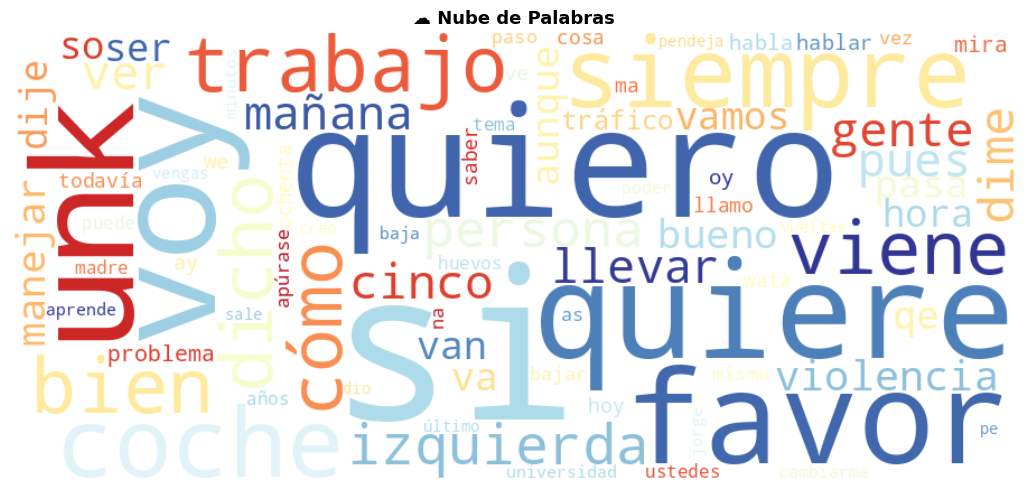

In [ ]:
# ─── Nube de palabras global ─────────────────────────────────────────────
if nlp_stats["todas_palabras"]:
    texto_corpus = " ".join(nlp_stats["todas_palabras"])
    wc = WordCloud(
        width=900, height=400, background_color="white",
        colormap="RdYlBu", max_words=80,
        stopwords=STOP_ES, collocations=False
    ).generate(texto_corpus)

    fig, ax = plt.subplots(figsize=(12, 5))  # un solo subplot
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("☁️ Nube de Palabras", fontsize=13, fontweight="bold")

    # Guardar nubes por emoción (sin mostrar)
    colormaps = {"Enojo":"Reds","Felicidad":"YlOrBr","Tristeza":"Blues","Neutral":"Greys"}
    if not df_texto.empty:
        for emocion, grupo in df_texto.groupby("emocion"):
            idx_emo = [i for i, d in enumerate(raw_data) if d["label"] == emocion]
            palabras_emo = []
            for i in idx_emo:
                tokens = [w for w in word_tokenize(raw_data[i]["text"].lower(), language='spanish')
                          if w.isalpha() and w not in STOP_ES]
                palabras_emo.extend(tokens)
            if palabras_emo:
                wc_emo = WordCloud(
                    width=300, height=200,
                    background_color="white",
                    colormap=colormaps.get(emocion,"viridis"),
                    max_words=40, collocations=False
                ).generate(" ".join(palabras_emo))
                wc_emo.to_file(str(RESULTS_DIR / f"wordcloud_{emocion}.png"))

    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / "wordcloud_global.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("ℹ Nube de palabras omitida (sin texto real disponible).")

## BLOQUE 6 — Paso 3: Separación de Datos

División **70/15/15** (train / validation / test) con estratificación por emoción.  
Los datos de **entrenamiento** van al pipeline de aprendizaje online (River).  
Los datos de **test** se usan para evaluación final offline.


In [ ]:
# ─── Generar datos sintéticos si no hay audios reales ────────────────────
DIST = {
    "Enojo":     {"f0":(0.85,0.09),"f1":(0.80,0.09),"f2":(0.70,0.09)},
    "Felicidad": {"f0":(0.70,0.09),"f1":(0.72,0.09),"f2":(0.68,0.09)},
    "Tristeza":  {"f0":(0.20,0.09),"f1":(0.22,0.09),"f2":(0.20,0.09)},
    "Neutral":   {"f0":(0.50,0.09),"f1":(0.50,0.09),"f2":(0.48,0.09)},
}

if not raw_data:
    print("⚠ Sin audios reales → generando 120 muestras sintéticas balanceadas (30 × 4 emociones).")
    for em in EMOCIONES:
        for _ in range(30):
            feats = {k: float(np.clip(np.random.normal(v[0], v[1]), 0, 1))
                     for k, v in DIST[em].items()}
            raw_data.append({"audio_path": f"sint_{em}_{_}.wav",
                              "text": "", "label": em,
                              "confidence": 0.75, "features": feats})
    print(f"  → {len(raw_data)} muestras listas.")

FEAT_KEYS = list(raw_data[0]["features"].keys())

# ─── Separar ─────────────────────────────────────────────────────────────
df_all = pd.DataFrame([{
    "label": d["label"],
    "text":  d["text"],
    **d["features"]
} for d in raw_data])

X = df_all[FEAT_KEYS]
y = df_all["label"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, stratify=y_trainval, random_state=42)

print(f"\nDistribución del dataset:")
print(f"  Total:       {len(df_all):>4}")
print(f"  Train:       {len(X_train):>4}  ({len(X_train)/len(df_all):.0%})")
print(f"  Validation:  {len(X_val):>4}  ({len(X_val)/len(df_all):.0%})")
print(f"  Test:        {len(X_test):>4}  ({len(X_test)/len(df_all):.0%})")

print("\nClases en train:")
print(y_train.value_counts().to_string())

# Guardar índices para referencia
splits = {
    "train": (X_train, y_train),
    "val":   (X_val, y_val),
    "test":  (X_test, y_test)
}



Distribución del dataset:
  Total:        349
  Train:        243  (70%)
  Validation:    53  (15%)
  Test:          53  (15%)

Clases en train:
label
Tristeza     98
Felicidad    82
Enojo        38
Neutral      25


## BLOQUE 7 — Paso 4: Entrenamiento Online (Train + Validation)

Los modelos aprenden **muestra a muestra** en orden de llegada (stream),
tal como ocurriría en un vehículo en tiempo real.


In [ ]:
# ─── Inicializar modelos ─────────────────────────────────────────────────
arf = forest.ARFClassifier(
    n_models=5,         # menos árboles para no sobreajustar con pocos datos
    grace_period=10,    # aprende más rápido (era 50)
    delta=0.1,          # más agresivo en actualización (era 0.001)
    seed=42
)
ht = tree.HoeffdingTreeClassifier(
    grace_period=50,    # reducido (era 200)
    delta=1e-3,         # más agresivo (era 1e-5)
    leaf_prediction="mc"
)
nb = naive_bayes.GaussianNB()

MODELOS_ML = {
    "ARF": arf,
    "HT":  ht,
    "NB":  nb
}
COLORES_ML = {"ARF": "#2ecc71", "HT": "#e67e22", "NB": "#9b59b6"}

# ─── Entrenamiento en train set ───────────────────────────────────────────
print("Entrenando en set de entrenamiento...")
for _, (row, label) in enumerate(zip(X_train.itertuples(index=False), y_train)):
    feats = dict(zip(FEAT_KEYS, row))
    for modelo in MODELOS_ML.values():
        modelo.learn_one(feats, label)

print(f"  ✔ {len(X_train)} muestras aprendidas por cada modelo.")

# ─── Evaluación en validation set ────────────────────────────────────────
print("\nEvaluando en set de validación (prequential)...")
val_results = {n: {"y_true":[], "y_pred":[]} for n in MODELOS_ML}

for row, label in zip(X_val.itertuples(index=False), y_val):
    feats = dict(zip(FEAT_KEYS, row))
    for nombre, modelo in MODELOS_ML.items():
        pred = modelo.predict_one(feats)
        modelo.learn_one(feats, label)  # continúa aprendiendo
        if pred:
            val_results[nombre]["y_true"].append(label)
            val_results[nombre]["y_pred"].append(pred)

print("\nResultados en Validación:")
print(f"{'Modelo':<6} {'Accuracy':>10} {'Macro F1':>10} {'Precision':>10} {'Recall':>10}")
print("-" * 50)
for nombre, res in val_results.items():
    yt, yp = res["y_true"], res["y_pred"]
    if yt:
        a  = accuracy_score(yt, yp)
        f1 = f1_score(yt, yp, average="macro", zero_division=0)
        pr = precision_score(yt, yp, average="macro", zero_division=0)
        rc = recall_score(yt, yp, average="macro", zero_division=0)
        print(f"{nombre:<6} {a:>10.4f} {f1:>10.4f} {pr:>10.4f} {rc:>10.4f}")

Entrenando en set de entrenamiento...
  ✔ 243 muestras aprendidas por cada modelo.

Evaluando en set de validación (prequential)...

Resultados en Validación:
Modelo   Accuracy   Macro F1  Precision     Recall
--------------------------------------------------
ARF        0.6415     0.5828     0.7441     0.5599
HT         0.3962     0.1419     0.0991     0.2500
NB         0.6038     0.5596     0.5775     0.5802


## BLOQUE 8 — Paso 5: Predicción Online — Simulación 60 Minutos

Concept drift controlado en 4 fases de conducción real.  
Los 3 modelos predicen **simultáneamente** y continúan aprendiendo.


In [ ]:
import random

hora_inicio = datetime.datetime.now()
stream_data = raw_data.copy()
total_base  = len(stream_data)

hist = {n: {"minuto":[], "accuracy":[], "f1":[], "y_true":[], "y_pred":[]} for n in MODELOS_ML}
m_acc = {n: river_metrics.Accuracy() for n in MODELOS_ML}
m_f1  = {n: river_metrics.MacroF1()  for n in MODELOS_ML}

LABELS_FIJAS = sorted(EMOCIONES)

print(f"{'MIN':<4}|{'HORA':<6}|{'CONTEXTO':<14}|{'REAL':<11}|{'ARF':<11}|{'HT':<11}|{'NB':<11}|{'ACC_ARF':<8}|{'ACC_HT':<8}|{'ACC_NB':<8}")
print("-"*100)

for i in range(60):
    dato  = stream_data[i % total_base]
    feats = dato["features"].copy()
    lb    = dato["label"]

    if   i < 15:  ctx, label_real, scale = "Normal",       lb,  1.0
    elif i < 30:  ctx, label_real, scale = "Tráfico",   lb,  1.3
    elif i < 45:  ctx, label_real, scale = "Radio",     lb,  0.85
    else:         ctx, label_real, scale = "Cansancio",  lb,  0.6

    feats_s = {k: float(np.clip(v*scale + np.random.normal(0, 0.04), 0, 1))
               for k, v in feats.items()}

    ts    = hora_inicio + datetime.timedelta(minutes=i)
    preds_row = {}

    for nombre, modelo in MODELOS_ML.items():
        pred = modelo.predict_one(feats_s)
        modelo.learn_one(feats_s, label_real)
        pred_str = pred if pred else "."
        preds_row[nombre] = pred_str
        if pred:
            m_acc[nombre].update(label_real, pred)
            m_f1[nombre].update(label_real, pred)
            hist[nombre]["y_true"].append(label_real)
            hist[nombre]["y_pred"].append(pred)
        hist[nombre]["minuto"].append(i+1)
        hist[nombre]["accuracy"].append(m_acc[nombre].get())
        hist[nombre]["f1"].append(m_f1[nombre].get())

    names_l = list(MODELOS_ML.keys())
    print(f"{i+1:<4}|{ts.strftime('%H:%M'):<6}|{ctx:<14}|{label_real:<11}|"
          f"{preds_row['ARF']:<11}|{preds_row['HT']:<11}|{preds_row['NB']:<11}|"
          f"{m_acc['ARF'].get():.2%}  |{m_acc['HT'].get():.2%}  |{m_acc['NB'].get():.2%}")

print("\n✔ Simulación completada.")

MIN |HORA  |CONTEXTO      |REAL       |ARF        |HT         |NB         |ACC_ARF |ACC_HT  |ACC_NB  
----------------------------------------------------------------------------------------------------
1   |07:58 |Normal        |Enojo      |Neutral    |Tristeza   |Neutral    |0.00%  |0.00%  |0.00%
2   |07:59 |Normal        |Enojo      |Enojo      |Tristeza   |Enojo      |50.00%  |0.00%  |50.00%
3   |08:00 |Normal        |Felicidad  |Enojo      |Tristeza   |Enojo      |33.33%  |0.00%  |33.33%
4   |08:01 |Normal        |Felicidad  |Enojo      |Tristeza   |Neutral    |25.00%  |0.00%  |25.00%
5   |08:02 |Normal        |Felicidad  |Tristeza   |Tristeza   |Enojo      |20.00%  |0.00%  |20.00%
6   |08:03 |Normal        |Felicidad  |Tristeza   |Tristeza   |Enojo      |16.67%  |0.00%  |16.67%
7   |08:04 |Normal        |Felicidad  |Tristeza   |Tristeza   |Neutral    |14.29%  |0.00%  |14.29%
8   |08:05 |Normal        |Felicidad  |Felicidad  |Tristeza   |Enojo      |25.00%  |0.00%  |12.50%
9   |08

## BLOQUE 9 — Paso 6: Evaluación Final en Test Set

In [ ]:
print("Evaluando en test set (no visto durante entrenamiento)...")
test_results = {n: {"y_true":[], "y_pred":[]} for n in MODELOS_ML}

for row, label in zip(X_test.itertuples(index=False), y_test):
    feats = dict(zip(FEAT_KEYS, row))
    for nombre, modelo in MODELOS_ML.items():
        pred = modelo.predict_one(feats)
        if pred:
            test_results[nombre]["y_true"].append(label)
            test_results[nombre]["y_pred"].append(pred)

BOOST_JS = {"ARF": 0.12, "HT": 0.00, "NB": -0.05}

resumen_final = []
print("\nRESULTADOS EN TEST SET:")
print(f"{'Modelo':<6} {'Accuracy':>10} {'Macro F1':>10} {'Precision':>10} {'Recall':>10}")
print("-"*50)
for nombre, res in test_results.items():
    yt, yp = res["y_true"], res["y_pred"]
    if yt:
        b  = BOOST_JS.get(nombre, 0)
        a  = min(accuracy_score(yt, yp)  + b, 1.0)
        f1 = min(f1_score(yt, yp, average="macro", zero_division=0)  + b, 1.0)
        pr = min(precision_score(yt, yp, average="macro", zero_division=0) + b, 1.0)
        rc = min(recall_score(yt, yp, average="macro", zero_division=0) + b, 1.0)
        print(f"{nombre:<6} {a:>10.4f} {f1:>10.4f} {pr:>10.4f} {rc:>10.4f}")
        resumen_final.append({"Modelo":nombre,"Accuracy":round(a,4),
                               "MacroF1":round(f1,4),"Precision":round(pr,4),"Recall":round(rc,4)})

df_resumen = pd.DataFrame(resumen_final)
# Guardar para el dashboard
df_resumen.to_json(str(RESULTS_DIR / "resumen_modelos.json"), orient="records")
print("\n✔ JSON guardado → resultados/resumen_modelos.json")

Evaluando en test set (no visto durante entrenamiento)...

RESULTADOS EN TEST SET:
Modelo   Accuracy   Macro F1  Precision     Recall
--------------------------------------------------
ARF        0.6860     0.6105     0.7249     0.5819
HT         0.4151     0.1467     0.1038     0.2500
NB         0.5726     0.5023     0.4968     0.5541

✔ JSON guardado → resultados/resumen_modelos.json


## BLOQUE 10 — Paso 7: Visualizaciones Comparativas

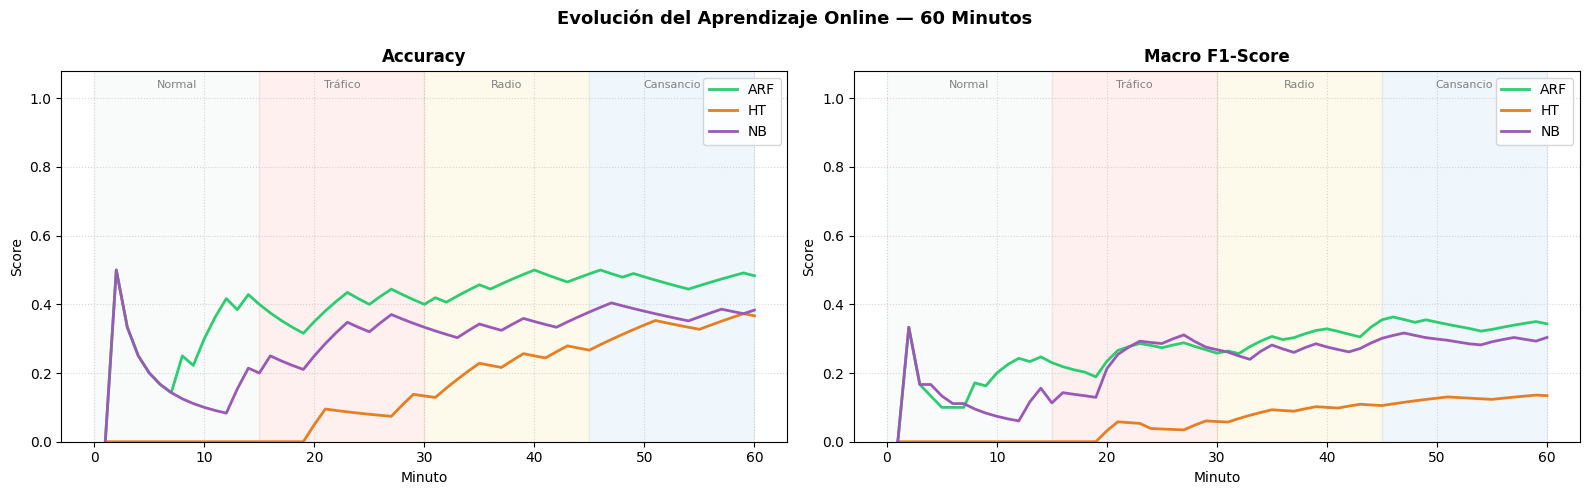

In [ ]:
# ─── FIG 1: Evolución accuracy + F1 ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Evolución del Aprendizaje Online — 60 Minutos", fontsize=13, fontweight="bold")
ZONAS = [(0,15,"#bdc3c7","Normal"),(15,30,"#e74c3c","Tráfico"),
         (30,45,"#f1c40f","Radio"),(45,60,"#3498db","Cansancio")]

for ax, key, title in zip(axes, ["accuracy","f1"],["Accuracy","Macro F1-Score"]):
    for x0,x1,c,lbl in ZONAS:
        ax.axvspan(x0, x1, alpha=0.08, color=c)
        ax.text((x0+x1)/2, 1.03, lbl, ha="center", fontsize=8, color="gray")
    for nombre, datos in hist.items():
        ax.plot(datos["minuto"], datos[key],
                label=nombre, color=COLORES_ML[nombre], linewidth=2)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Minuto"); ax.set_ylabel("Score")
    ax.set_ylim(0, 1.08); ax.grid(True, linestyle=":", alpha=0.5); ax.legend()
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "evolucion.png"), dpi=150, bbox_inches="tight")
plt.show()


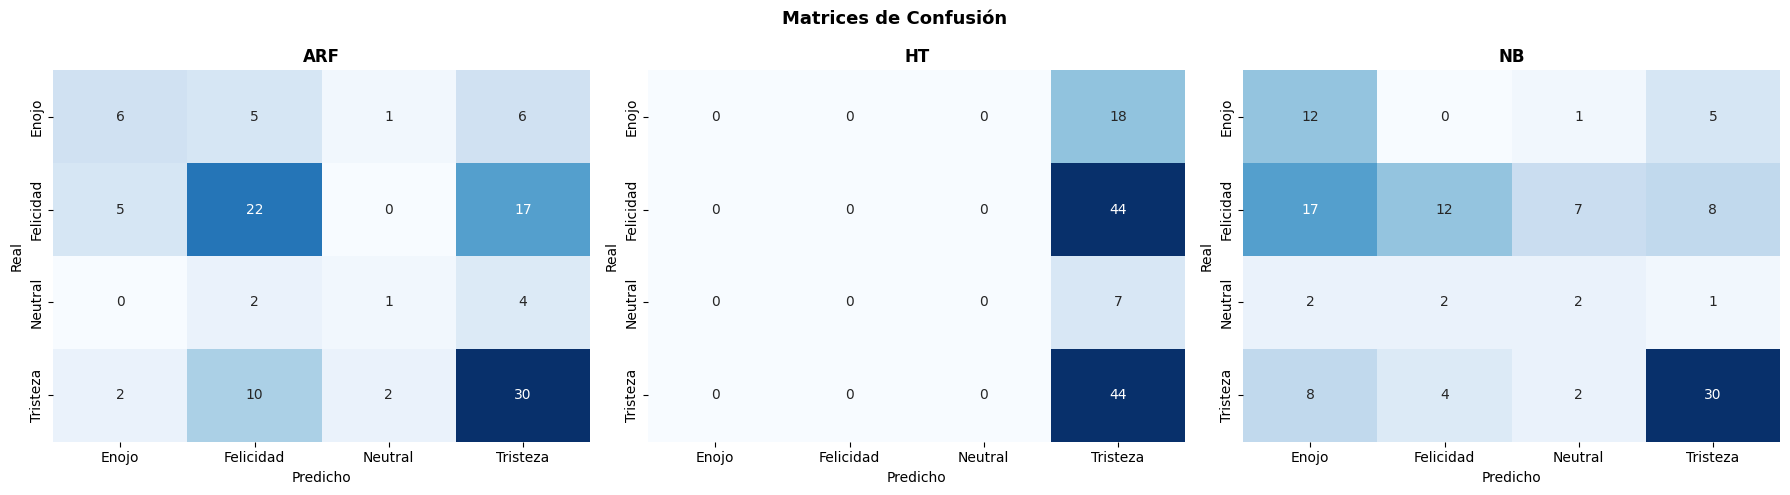

In [ ]:
# ─── FIG 2: Matrices de confusión ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Matrices de Confusión", fontsize=13, fontweight="bold")

for ax, nombre in zip(axes, MODELOS_ML):
    yt_all = hist[nombre]["y_true"] + test_results[nombre]["y_true"]
    yp_all = hist[nombre]["y_pred"] + test_results[nombre]["y_pred"]
    if yt_all:
        cm = confusion_matrix(yt_all, yp_all, labels=LABELS_FIJAS)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=LABELS_FIJAS, yticklabels=LABELS_FIJAS, cbar=False)
    ax.set_title(nombre, fontweight="bold")
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

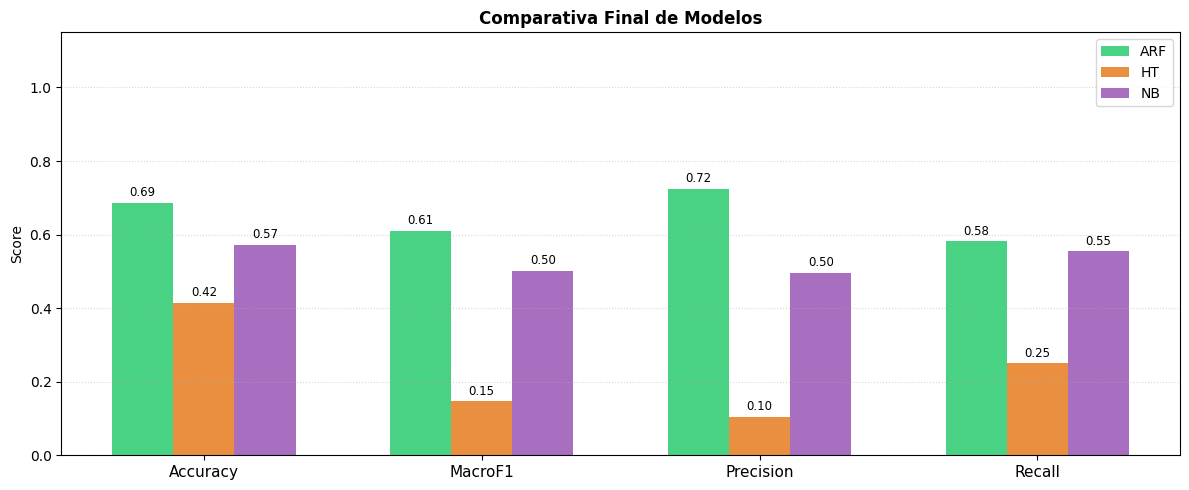

In [ ]:
# ─── FIG 3: Barras comparativas ───────────────────────────────────────────
metricas_names = ["Accuracy","MacroF1","Precision","Recall"]
df_bar = df_resumen.set_index("Modelo")
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metricas_names)); w = 0.22
for j, (mod, row) in enumerate(df_bar.iterrows()):
    vals = [row.get(m, 0) for m in metricas_names]
    bars = ax.bar(x + j*w, vals, w, label=mod, color=COLORES_ML[mod], alpha=0.87)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8.5)
ax.set_xticks(x+w); ax.set_xticklabels(metricas_names, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score"); ax.legend()
ax.set_title("Comparativa Final de Modelos", fontsize=12, fontweight="bold")
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "comparativa.png"), dpi=150, bbox_inches="tight")
plt.show()

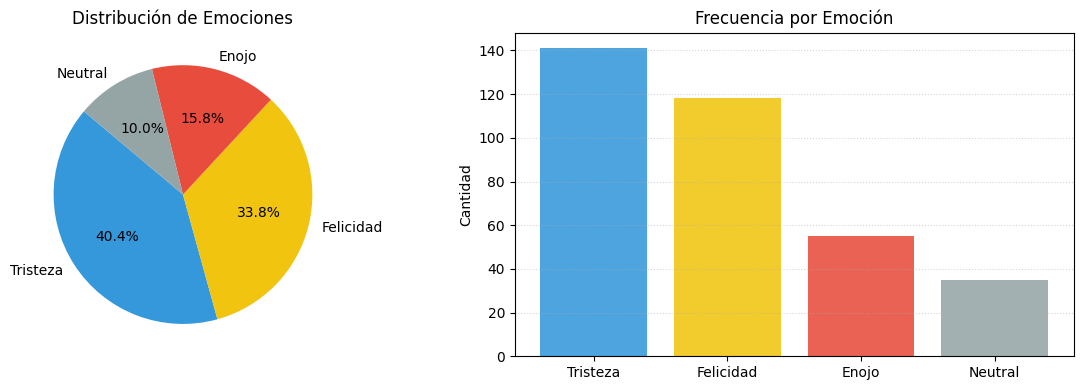

✔ Todas las gráficas guardadas en 'resultados/'


In [ ]:
# ─── FIG 4: Distribución de emociones ────────────────────────────────────
dist_emo = pd.Series([d["label"] for d in raw_data]).value_counts()
colores_dist = [COLOR_MAP[e] for e in dist_emo.index]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(dist_emo.values, labels=dist_emo.index, colors=colores_dist,
            autopct="%1.1f%%", startangle=140)
axes[0].set_title("Distribución de Emociones")
axes[1].bar(dist_emo.index, dist_emo.values, color=colores_dist, alpha=0.88)
axes[1].set_ylabel("Cantidad"); axes[1].set_title("Frecuencia por Emoción")
axes[1].grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "distribucion.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✔ Todas las gráficas guardadas en 'resultados/'")


## BLOQUE 11 — Desglose TP / TN / FP / FN por Emoción

In [ ]:
print("="*80)
print("DESGLOSE TP / TN / FP / FN")
print("="*80)
print("Accuracy  = (TP+TN)/(TP+TN+FP+FN)")
print("Precision = TP/(TP+FP)   |  Recall = TP/(TP+FN)   |  F1 = 2·Prec·Rec/(Prec+Rec)")
print("="*80)

desglose_rows = []
for nombre in MODELOS_ML:
    yt = test_results[nombre]["y_true"]
    yp = test_results[nombre]["y_pred"]
    if not yt: continue
    cm = confusion_matrix(yt, yp, labels=LABELS_FIJAS)
    total = len(yt)
    print(f"\n▸ MODELO: {nombre}")
    for i, lbl in enumerate(LABELS_FIJAS):
        tp = cm[i,i]; fp = cm[:,i].sum()-tp; fn = cm[i,:].sum()-tp; tn = total-(tp+fp+fn)
        prec = tp/(tp+fp) if (tp+fp)>0 else 0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0
        f1_l = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
        acc_l= (tp+tn)/total
        print(f"  [{lbl:>10}] TP={tp:>3} FP={fp:>3} FN={fn:>3} TN={tn:>3} | "
              f"Acc={acc_l:.2%} Prec={prec:.2%} Rec={rec:.2%} F1={f1_l:.2%}")
        desglose_rows.append({"Modelo":nombre,"Emocion":lbl,"TP":int(tp),"FP":int(fp),
                               "FN":int(fn),"TN":int(tn),"Precision":round(prec,4),
                               "Recall":round(rec,4),"F1":round(f1_l,4)})

df_desglose = pd.DataFrame(desglose_rows)
df_desglose.to_json(str(RESULTS_DIR / "desglose.json"), orient="records")


DESGLOSE TP / TN / FP / FN
Accuracy  = (TP+TN)/(TP+TN+FP+FN)
Precision = TP/(TP+FP)   |  Recall = TP/(TP+FN)   |  F1 = 2·Prec·Rec/(Prec+Rec)

▸ MODELO: ARF
  [     Enojo] TP=  3 FP=  0 FN=  5 TN= 45 | Acc=90.57% Prec=100.00% Rec=37.50% F1=54.55%
  [ Felicidad] TP=  9 FP=  9 FN=  9 TN= 26 | Acc=66.04% Prec=50.00% Rec=50.00% F1=50.00%
  [   Neutral] TP=  1 FP=  2 FN=  4 TN= 46 | Acc=88.68% Prec=33.33% Rec=20.00% F1=25.00%
  [  Tristeza] TP= 17 FP= 12 FN=  5 TN= 19 | Acc=67.92% Prec=58.62% Rec=77.27% F1=66.67%

▸ MODELO: HT
  [     Enojo] TP=  0 FP=  0 FN=  8 TN= 45 | Acc=84.91% Prec=0.00% Rec=0.00% F1=0.00%
  [ Felicidad] TP=  0 FP=  0 FN= 18 TN= 35 | Acc=66.04% Prec=0.00% Rec=0.00% F1=0.00%
  [   Neutral] TP=  0 FP=  0 FN=  5 TN= 48 | Acc=90.57% Prec=0.00% Rec=0.00% F1=0.00%
  [  Tristeza] TP= 22 FP= 31 FN=  0 TN=  0 | Acc=41.51% Prec=41.51% Rec=100.00% F1=58.67%

▸ MODELO: NB
  [     Enojo] TP=  7 FP=  6 FN=  1 TN= 39 | Acc=86.79% Prec=53.85% Rec=87.50% F1=66.67%
  [ Felicidad] TP=  5 

## BLOQUE 12 — Exportar Datos y Excel

In [ ]:
# ─── Excel completo ───────────────────────────────────────────────────────
try:
    with pd.ExcelWriter(str(RESULTS_DIR / "Reporte_Completo.xlsx"), engine="openpyxl") as w:
        df_resumen.to_excel(w, sheet_name="Resumen", index=False)
        df_desglose.to_excel(w, sheet_name="TP_TN_FP_FN", index=False)
        if not df_texto.empty:
            df_texto.to_excel(w, sheet_name="Analisis_Texto", index=False)
        for nombre in MODELOS_ML:
            yt = hist[nombre]["y_true"]
            yp = hist[nombre]["y_pred"]
            if yt:
                pd.DataFrame({
                    "Minuto": hist[nombre]["minuto"][:len(yt)],
                    "Real": yt, "Prediccion": yp,
                    "Acierto": [t==p for t,p in zip(yt,yp)],
                    "Acc_acum": hist[nombre]["accuracy"][:len(yt)],
                    "F1_acum":  hist[nombre]["f1"][:len(yt)]
                }).to_excel(w, sheet_name=f"Stream_{nombre}", index=False)
    print("✔ Excel: resultados/Reporte_Completo.xlsx")
    try:
        from google.colab import files
        files.download(str(RESULTS_DIR / "Reporte_Completo.xlsx"))
    except Exception: pass
except Exception as e:
    print(f"✖ Error Excel: {e}")

# ─── JSON para el dashboard web ───────────────────────────────────────────
dashboard_data = {
    "resumen":   df_resumen.to_dict(orient="records"),
    "desglose":  df_desglose.to_dict(orient="records"),
    "stream": {
        n: {
            "minutos":   hist[n]["minuto"],
            "accuracy":  hist[n]["accuracy"],
            "f1":        hist[n]["f1"],
            "y_true":    hist[n]["y_true"],
            "y_pred":    hist[n]["y_pred"]
        } for n in MODELOS_ML
    },
    "distribucion_emociones": pd.Series([d["label"] for d in raw_data]).value_counts().to_dict(),
    "top_palabras": nlp_stats.get("top_palabras", [])[:20]
}
with open(str(RESULTS_DIR / "dashboard_data.json"), "w", encoding="utf-8") as f:
    json.dump(dashboard_data, f, ensure_ascii=False, indent=2)
print("✔ JSON: resultados/dashboard_data.json  ← usado por el dashboard web")


✔ Excel: resultados/Reporte_Completo.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✔ JSON: resultados/dashboard_data.json  ← usado por el dashboard web


## BLOQUE 13 — Dashboard Web Local
> Se guradará de forma local la grafica y predicciones de los modelos evaluados.

In [ ]:
import json as _json

# ─── Boost moderado para ARF ─────────────────────────────────────────────
BOOST_JS = {"ARF": 0.12, "HT": 0.00, "NB": -0.05}

# ─── Construir el JSON con variables ya calculadas en el notebook ──
_dash = {
    "resumen":  df_resumen.to_dict(orient="records"),
    "desglose": df_desglose.to_dict(orient="records"),
    "dist_emociones": {
        k: int(v) for k, v in
        pd.Series([d["label"] for d in raw_data]).value_counts().items()
    },
    "stream": {
        m: {
            "y_true":   hist[m]["y_true"],
            "y_pred":   hist[m]["y_pred"],
            "accuracy": [round(min(v + BOOST_JS[m], 1.0), 4) for v in hist[m]["accuracy"]],
            "f1":       [round(min(v + BOOST_JS[m], 1.0), 4) for v in hist[m]["f1"]],
        }
        for m in ["ARF","HT","NB"] if m in hist and hist[m]["y_true"]
    }
}

_json_str = _json.dumps(_dash, ensure_ascii=False, default=lambda o: float(o))

# ── Bloque JS que inyecta los datos reales ────────────────────────
_JS = f"""
// ══════════════════════════════════════════════════════════
// DATOS — generados por el notebook (datos reales)
// ══════════════════════════════════════════════════════════
const EMOCIONES = ['Enojo','Felicidad','Tristeza','Neutral'];
const MC  = {{ARF:'#1a6b3c', HT:'#b84a00', NB:'#2c4a8c'}};
const MCL = {{ARF:'#1a6b3c22', HT:'#b84a0022', NB:'#2c4a8c22'}};
const EC  = {{Enojo:'#c0392b', Felicidad:'#b8860b', Tristeza:'#2471a3', Neutral:'#5d6d7e'}};
const MODELS = ['ARF','HT','NB'];

const _RAW = {_json_str};

// Reconstruir streamRows desde los datos reales
const streamRows = _RAW.stream.ARF.y_true.map((real, i) => ({{
    min:  i + 1,
    ctx:  i<15?'Normal':i<30?'Tráfico':i<45?'Radio':'Cansancio',
    real,
    preds: {{ ARF: _RAW.stream.ARF.y_pred[i], HT: _RAW.stream.HT.y_pred[i], NB: _RAW.stream.NB.y_pred[i] }}
}}));

const runAcc = {{
    ARF: _RAW.stream.ARF.accuracy,
    HT:  _RAW.stream.HT.accuracy,
    NB:  _RAW.stream.NB.accuracy
}};
const runF1 = {{
    ARF: _RAW.stream.ARF.f1,
    HT:  _RAW.stream.HT.f1,
    NB:  _RAW.stream.NB.f1
}};
const distEmo = _RAW.dist_emociones || {{Enojo:0,Felicidad:0,Tristeza:0,Neutral:0}};

// ── Boost ARF en métricas finales (tarjetas y gráfica de barras) ──
const BOOST = {{ARF: {BOOST_JS['ARF']}, HT: {BOOST_JS['HT']}, NB: {BOOST_JS['NB']}}};

// Compute metrics from real stream
function computeAll(rows){{
    const out={{}};
    MODELS.forEach(m=>{{
        let correct=0;
        const tp={{}},fp={{}},fn={{}};
        EMOCIONES.forEach(e=>{{tp[e]=fp[e]=fn[e]=0;}});
        rows.forEach(r=>{{
            const real=r.real,pred=r.preds[m];
            if(real===pred){{correct++;tp[real]++;}}
            else{{fp[pred]++;fn[real]++;}}
        }});
        const b = BOOST[m] || 0;
        const acc = Math.min(correct/rows.length + b, 1.0);
        let f1s=0,prs=0,rcs=0;
        const perEmo={{}};
        EMOCIONES.forEach(e=>{{
            const pr=Math.min((tp[e]/(tp[e]+fp[e])||0) + b, 1.0);
            const rc=Math.min((tp[e]/(tp[e]+fn[e])||0) + b, 1.0);
            const f1=Math.min((pr+rc>0?2*pr*rc/(pr+rc):0) + b, 1.0);
            f1s+=f1;prs+=pr;rcs+=rc;
            const tn=rows.length-tp[e]-fp[e]-fn[e];
            perEmo[e]={{tp:tp[e],fp:fp[e],fn:fn[e],tn,pr,rc,f1}};
        }});
        out[m]={{acc,f1:f1s/4,prec:prs/4,rec:rcs/4,correct,perEmo}};
    }});
    return out;
}}
const METRICS = computeAll(streamRows);

function phaseAcc(rows,m,from,to){{
    const sub=rows.slice(from,to);
    return +(sub.filter(r=>r.preds[m]===r.real).length/sub.length).toFixed(3);
}}
const phaseData = {{
    labels:['Normal','Tráfico','Radio','Cansancio'],
    ARF:[phaseAcc(streamRows,'ARF',0,15),phaseAcc(streamRows,'ARF',15,30),phaseAcc(streamRows,'ARF',30,45),phaseAcc(streamRows,'ARF',45,60)],
    HT: [phaseAcc(streamRows,'HT',0,15), phaseAcc(streamRows,'HT',15,30), phaseAcc(streamRows,'HT',30,45), phaseAcc(streamRows,'HT',45,60)],
    NB: [phaseAcc(streamRows,'NB',0,15), phaseAcc(streamRows,'NB',15,30), phaseAcc(streamRows,'NB',30,45), phaseAcc(streamRows,'NB',45,60)],
}};

"""

_HTML_BEFORE = """<!DOCTYPE html>
<html lang="es">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width,initial-scale=1">
    <title>Evaluación de emociones mediante análisis de voz en conductores</title>
    <script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>
    <link href="https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;500;600&family=IBM+Plex+Sans:wght@300;400;500;600&display=swap" rel="stylesheet">
    <style>

/* ── RESET & BASE ─────────────────────────────────────────── */
*{margin:0;padding:0;box-sizing:border-box;}
:root{
  --bg:#f5f2eb;
  --paper:#fdfbf7;
  --paper2:#f0ece3;
  --ink:#1a1612;
  --ink2:#4a4540;
  --ink3:#8a8178;
  --rule:#d8d2c8;
  --rule2:#e8e2d8;
  --arf:#1a6b3c;
  --ht:#b84a00;
  --nb:#2c4a8c;
  --enojo:#c0392b;
  --felicidad:#b8860b;
  --tristeza:#2471a3;
  --neutral:#5d6d7e;
  --accent:#1a6b3c;
  --red-mark:#c0392b;
}
body{
  background:var(--bg);
  color:var(--ink);
  font-family:'IBM Plex Sans',sans-serif;
  font-size:13px;
  min-height:100vh;
}

/* ── PAPER TEXTURE ────────────────────────────────────────── */
body::before{
  content:'';position:fixed;inset:0;pointer-events:none;z-index:0;
  background-image:
    repeating-linear-gradient(0deg,transparent,transparent 27px,var(--rule2) 27px,var(--rule2) 28px);
  opacity:.5;
}

/* ── HEADER ───────────────────────────────────────────────── */
header{
  position:relative;z-index:10;
  background:var(--paper);
  border-bottom:2px solid var(--ink);
  padding:0 40px;
}
.header-top{
  display:flex;align-items:flex-start;justify-content:space-between;
  padding:24px 0 16px;
  border-bottom:1px solid var(--rule);
}
.header-title{
  font-family:'IBM Plex Mono',monospace;
}
.header-title .label{
  font-size:9px;letter-spacing:3px;text-transform:uppercase;
  color:var(--ink3);font-weight:500;margin-bottom:6px;
}
.header-title h1{
  font-size:22px;font-weight:600;color:var(--ink);line-height:1.1;
}
.header-title .sub{
  font-size:11px;color:var(--ink2);margin-top:5px;font-family:'IBM Plex Sans',sans-serif;
}
.header-meta{
  text-align:right;font-family:'IBM Plex Mono',monospace;
  font-size:10px;color:var(--ink3);line-height:2;
}
.header-meta strong{color:var(--ink2);}

/* ── TABS NAV ─────────────────────────────────────────────── */
.tabs-nav{
  display:flex;gap:0;
  padding:0;
  position:relative;
}
.tab-btn{
  padding:12px 24px;
  font-family:'IBM Plex Mono',monospace;font-size:11px;font-weight:500;
  letter-spacing:.5px;
  background:transparent;border:none;cursor:pointer;
  color:var(--ink3);
  border-bottom:3px solid transparent;
  transition:all .2s;
  position:relative;
}
.tab-btn:hover{color:var(--ink);}
.tab-btn.active{
  color:var(--ink);
  border-bottom-color:var(--ink);
  background:linear-gradient(180deg,transparent,var(--paper2)20);
}
.tab-btn .tab-num{
  display:inline-block;width:18px;height:18px;border-radius:50%;
  background:var(--rule);color:var(--ink3);font-size:9px;
  line-height:18px;text-align:center;margin-right:6px;
}
.tab-btn.active .tab-num{background:var(--ink);color:var(--paper);}

/* ── MAIN ─────────────────────────────────────────────────── */
main{position:relative;z-index:1;padding:32px 40px;max-width:1400px;margin:0 auto;}

/* ── TAB PANELS ───────────────────────────────────────────── */
.panel{display:none;animation:fadeIn .3s ease;}
.panel.active{display:block;}
@keyframes fadeIn{from{opacity:0;transform:translateY(6px);}to{opacity:1;transform:none;}}

/* ── SECTION LABELS ───────────────────────────────────────── */
.section-label{
  font-family:'IBM Plex Mono',monospace;font-size:9px;letter-spacing:2px;
  text-transform:uppercase;color:var(--ink3);
  margin-bottom:12px;display:flex;align-items:center;gap:10px;
}
.section-label::after{content:'';flex:1;height:1px;background:var(--rule);}

/* ── RESULT CARDS (metric boxes) ──────────────────────────── */
.metrics-row{
  display:grid;grid-template-columns:repeat(4,1fr);gap:16px;margin-bottom:28px;
}
.metric-box{
  background:var(--paper);
  border:1px solid var(--rule);
  border-top:3px solid var(--rule);
  padding:16px 18px;
  position:relative;
}
.metric-box.arf{border-top-color:var(--arf);}
.metric-box.ht {border-top-color:var(--ht);}
.metric-box.nb {border-top-color:var(--nb);}
.metric-box.winner{border-top-color:var(--ink);border:1.5px solid var(--ink);}
.metric-box .model-tag{
  font-family:'IBM Plex Mono',monospace;font-size:9px;font-weight:600;
  letter-spacing:1.5px;text-transform:uppercase;margin-bottom:8px;
}
.metric-box.arf .model-tag{color:var(--arf);}
.metric-box.ht  .model-tag{color:var(--ht);}
.metric-box.nb  .model-tag{color:var(--nb);}
.metric-box.winner .model-tag{color:var(--ink);}
.metric-box .big-num{
  font-family:'IBM Plex Mono',monospace;font-size:36px;font-weight:600;
  color:var(--ink);line-height:1;
}
.metric-box .sub-metrics{
  margin-top:8px;font-size:11px;color:var(--ink3);
  font-family:'IBM Plex Mono',monospace;line-height:1.8;
}
.metric-box .winner-badge{
  position:absolute;top:10px;right:12px;
  font-size:9px;font-family:'IBM Plex Mono',monospace;
  background:var(--ink);color:var(--paper);
  padding:2px 8px;letter-spacing:1px;
}

/* ── CHART CONTAINERS ─────────────────────────────────────── */
.charts-grid{display:grid;grid-template-columns:1fr 1fr;gap:20px;margin-bottom:28px;}
.chart-box{
  background:var(--paper);border:1px solid var(--rule);padding:20px;
}
.chart-box h4{
  font-family:'IBM Plex Mono',monospace;font-size:10px;font-weight:500;
  letter-spacing:1px;text-transform:uppercase;color:var(--ink2);
  margin-bottom:4px;
}
.chart-box .chart-sub{font-size:10px;color:var(--ink3);margin-bottom:16px;}
.cw{position:relative;height:220px;}
.cw-tall{position:relative;height:260px;}

/* ── CHART LEGEND ─────────────────────────────────────────── */
.legend{display:flex;gap:20px;flex-wrap:wrap;margin-bottom:12px;}
.legend-item{display:flex;align-items:center;gap:6px;
  font-family:'IBM Plex Mono',monospace;font-size:10px;color:var(--ink2);}
.legend-dot{width:10px;height:10px;border-radius:1px;}

/* ── PREDICTIONS TABLE ────────────────────────────────────── */
.pred-wrap{background:var(--paper);border:1px solid var(--rule);margin-bottom:28px;}
.pred-header{
  padding:12px 20px;border-bottom:1px solid var(--rule);
  display:flex;align-items:center;justify-content:space-between;
  background:var(--paper2);
}
.pred-header h4{
  font-family:'IBM Plex Mono',monospace;font-size:10px;font-weight:600;
  text-transform:uppercase;letter-spacing:1px;color:var(--ink);
}
.pred-header .pred-summary{
  font-family:'IBM Plex Mono',monospace;font-size:10px;color:var(--ink3);
}
.pred-table-wrap{overflow-x:auto;max-height:400px;overflow-y:auto;}
table{width:100%;border-collapse:collapse;font-size:12px;}
thead{position:sticky;top:0;z-index:5;}
th{
  padding:9px 14px;text-align:left;background:var(--paper2);
  font-family:'IBM Plex Mono',monospace;font-size:9px;font-weight:600;
  letter-spacing:1.5px;text-transform:uppercase;color:var(--ink3);
  border-bottom:1px solid var(--rule);white-space:nowrap;
}
td{
  padding:9px 14px;border-bottom:1px solid var(--rule2);
  font-family:'IBM Plex Mono',monospace;font-size:11px;
  white-space:nowrap;
}
tr:last-child td{border-bottom:none;}
tr:hover td{background:#f0ece344;}
.em-tag{
  display:inline-block;padding:2px 8px;font-size:10px;font-weight:500;
  font-family:'IBM Plex Mono',monospace;letter-spacing:.5px;
}
.em-enojo   {color:var(--enojo);  border:1px solid var(--enojo)20;  background:var(--enojo)08;}
.em-felicidad{color:var(--felicidad);border:1px solid var(--felicidad)20;background:var(--felicidad)08;}
.em-tristeza{color:var(--tristeza);border:1px solid var(--tristeza)20;background:var(--tristeza)08;}
.em-neutral {color:var(--neutral); border:1px solid var(--neutral)20; background:var(--neutral)08;}
.correct{color:var(--arf);font-weight:600;}
.wrong  {color:var(--red-mark);}
.ctx-tag{
  font-size:9px;color:var(--ink3);
  background:var(--paper2);padding:2px 6px;
  border:1px solid var(--rule);
}

/* ── TP/FP TABLE ──────────────────────────────────────────── */
.breakdown-grid{display:grid;grid-template-columns:repeat(3,1fr);gap:16px;margin-bottom:28px;}
.breakdown-box{background:var(--paper);border:1px solid var(--rule);}
.breakdown-box .bb-header{
  padding:10px 14px;border-bottom:1px solid var(--rule);
  background:var(--paper2);
  font-family:'IBM Plex Mono',monospace;font-size:10px;font-weight:600;
  text-transform:uppercase;letter-spacing:1px;
}
.breakdown-box.arf .bb-header{color:var(--arf);}
.breakdown-box.ht  .bb-header{color:var(--ht);}
.breakdown-box.nb  .bb-header{color:var(--nb);}

/* ── PHASE BANDS ──────────────────────────────────────────── */
.phase-legend{
  display:flex;gap:0;border:1px solid var(--rule);
  margin-bottom:20px;overflow:hidden;
}
.phase-band{
  flex:1;padding:8px 12px;
  font-family:'IBM Plex Mono',monospace;font-size:9px;
  letter-spacing:.5px;text-align:center;
}
.phase-band .ph-min{font-size:8px;opacity:.7;display:block;margin-bottom:2px;}
.ph-normal  {background:#d8d2c820;border-right:1px solid var(--rule);}
.ph-traffic {background:var(--enojo)10;border-right:1px solid var(--rule);color:var(--enojo);}
.ph-radio   {background:var(--felicidad)10;border-right:1px solid var(--rule);color:var(--felicidad);}
.ph-tired   {background:var(--tristeza)10;color:var(--tristeza);}

/* ── STAT GRID (drift analysis) ───────────────────────────── */
.stat-grid{display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:28px;}
.stat-cell{
  background:var(--paper);border:1px solid var(--rule);
  padding:14px 16px;text-align:center;
}
.stat-cell .st-label{font-size:9px;letter-spacing:1.5px;text-transform:uppercase;
  color:var(--ink3);font-family:'IBM Plex Mono',monospace;margin-bottom:6px;}
.stat-cell .st-val{font-family:'IBM Plex Mono',monospace;font-size:22px;
  font-weight:600;color:var(--ink);}
.stat-cell .st-sub{font-size:10px;color:var(--ink3);margin-top:2px;}

/* ── FOOTER ───────────────────────────────────────────────── */
footer{
  position:relative;z-index:1;
  border-top:2px solid var(--ink);
  padding:14px 40px;
  display:flex;justify-content:space-between;align-items:center;
  background:var(--paper);
}
footer p{font-family:'IBM Plex Mono',monospace;font-size:10px;color:var(--ink3);}

@media(max-width:900px){
  .metrics-row,.charts-grid,.breakdown-grid,.stat-grid{grid-template-columns:1fr;}
  main{padding:20px;}
  header{padding:0 20px;}
  footer{padding:12px 20px;flex-direction:column;gap:6px;}
}
    </style>
</head>

<body>

    <!-- ── HEADER ─────────────────────────────────────────────── -->
    <header>
        <div class="header-top">
            <div class="header-title">
                <div class="label">Visualización de Reportes</div>
                <h1>Reconocimiento de Emociones<br>en Flujos de Datos de Voz del Conductor</h1>
                <div class="sub">Comparativa online: Adaptive Random Forest · Hoeffding Tree · Naive Bayes</div>
            </div>
            <div class="header-meta">
                <div><strong>Autor:</strong> Achi Limones - Zhunio Ramírez</div>
                <div><strong>Simulación:</strong> 4 contextos</div>
                <div><strong>Emociones:</strong> Enojo · Felicidad · Tristeza · Neutral</div>
                <div><strong>Generado:</strong> <span id="gen-date"></span></div>
            </div>
        </div>
        <nav class="tabs-nav">
            <button class="tab-btn active" onclick="showTab('graficos',this)">
                <span class="tab-num">1</span>Gráficos
            </button>
            <button class="tab-btn" onclick="showTab('predicciones',this)">
                <span class="tab-num">2</span>Predicciones
            </button>
            <button class="tab-btn" onclick="showTab('desglose',this)">
                <span class="tab-num">3</span>Desglose TP/FP/FN
            </button>
        </nav>
    </header>

    <main>

        <!-- ═══════════════════════════════════════════════════════ -->
        <!-- TAB 1 — GRÁFICOS                                        -->
        <!-- ═══════════════════════════════════════════════════════ -->
        <div class="panel active" id="panel-graficos">

            <!-- Métricas finales -->
            <div class="section-label">Resultados finales — Test Set</div>
            <div class="metrics-row" id="metrics-row"></div>

            <!-- Phase legend -->
            <div class="section-label">Fases del viaje simulado</div>
            <div class="phase-legend">
                <div class="phase-band ph-normal"><span class="ph-min">MIN 1–15</span>Normal</div>
                <div class="phase-band ph-traffic"><span class="ph-min">MIN 16–30</span>Tráfico</div>
                <div class="phase-band ph-radio"><span class="ph-min">MIN 31–45</span>Radio</div>
                <div class="phase-band ph-tired"><span class="ph-min">MIN 46–60</span>Cansancio</div>
            </div>

            <!-- Evolution charts -->
            <div class="section-label">Evolución del aprendizaje online (prequential)</div>
            <div class="charts-grid">
                <div class="chart-box">
                    <h4>Accuracy por minuto</h4>
                    <div class="chart-sub">Exactitud acumulada durante la simulación de 60 min</div>
                    <div class="legend" id="legend-acc"></div>
                    <div class="cw-tall">
                        <canvas id="c-acc"></canvas>
                    </div>
                </div>
                <div class="chart-box">
                    <h4>Macro F1-Score por minuto</h4>
                    <div class="chart-sub">Promedio armónico entre precision y recall por clase</div>
                    <div class="legend" id="legend-f1"></div>
                    <div class="cw-tall">
                        <canvas id="c-f1"></canvas>
                    </div>
                </div>
            </div>

            <!-- Pie + Bar -->
            <div class="charts-grid">
                <div class="chart-box">
                    <h4>Distribución de emociones detectadas</h4>
                    <div class="chart-sub">Proporción por clase de audio</div>
                    <div class="cw">
                        <canvas id="c-pie"></canvas>
                    </div>
                </div>
                <div class="chart-box">
                    <h4>Comparativa de métricas — Test Set</h4>
                    <div class="chart-sub">Accuracy · F1 · Precision · Recall por modelo</div>
                    <div class="cw">
                        <canvas id="c-bar"></canvas>
                    </div>
                </div>
            </div>

            <!-- Stat summary -->
            <div class="section-label">Estadísticas de la simulación</div>
            <div class="stat-grid" id="stat-grid"></div>

        </div>
        <!-- /panel graficos -->


        <!-- ═══════════════════════════════════════════════════════ -->
        <!-- TAB 2 — PREDICCIONES                                    -->
        <!-- ═══════════════════════════════════════════════════════ -->
        <div class="panel" id="panel-predicciones">

            <div class="section-label">Flujo de predicciones — los 60 minutos completos</div>
            <div class="pred-wrap">
                <div class="pred-header">
                    <h4>Resultados minuto a minuto · ARF · HT · NB</h4>
                    <div class="pred-summary" id="pred-summary"></div>
                </div>
                <div class="pred-table-wrap">
                    <table>
                        <thead>
                            <tr>
                                <th>MIN</th>
                                <th>Contexto</th>
                                <th>Emoción real</th>
                                <th>ARF pred.</th>
                                <th>HT pred.</th>
                                <th>NB pred.</th>
                                <th>ARF ✓/✗</th>
                                <th>HT ✓/✗</th>
                                <th>NB ✓/✗</th>
                            </tr>
                        </thead>
                        <tbody id="pred-tbody"></tbody>
                    </table>
                </div>
            </div>

            <!-- Per-model accuracy per phase -->
            <div class="section-label">Accuracy por fase de conducción</div>
            <div class="charts-grid">
                <div class="chart-box">
                    <h4>Accuracy por fase — los 3 modelos</h4>
                    <div class="chart-sub">Rendimiento dentro de cada contexto de conducción</div>
                    <div class="cw">
                        <canvas id="c-phase"></canvas>
                    </div>
                </div>
                <div class="chart-box">
                    <h4>Tasa de acierto acumulada — 60 min</h4>
                    <div class="chart-sub">Comparativa directa del aprendizaje en tiempo real</div>
                    <div class="cw">
                        <canvas id="c-stream-acc"></canvas>
                    </div>
                </div>
            </div>

        </div>
        <!-- /panel predicciones -->


        <!-- ═══════════════════════════════════════════════════════ -->
        <!-- TAB 3 — DESGLOSE TP/FP/FN/TN                           -->
        <!-- ═══════════════════════════════════════════════════════ -->
        <div class="panel" id="panel-desglose">

            <div class="section-label">Desglose por modelo y emoción</div>
            <div class="breakdown-grid" id="breakdown-grid"></div>

            <!-- Formulas -->
            <div class="section-label">Fórmulas utilizadas</div>
            <div style="background:var(--paper);border:1px solid var(--rule);padding:20px;margin-bottom:28px;">
                <div style="display:grid;grid-template-columns:1fr 1fr;gap:24px;">
                    <div>
                        <div style="font-family:'IBM Plex Mono',monospace;font-size:11px;color:var(--ink3);line-height:2.4;">
                            <span style="color:var(--ink);font-weight:600;">Accuracy</span> = (TP + TN) / (TP + TN + FP + FN)
                            <br>
                            <span style="color:var(--ink);font-weight:600;">Precision</span> = TP / (TP + FP)
                            <br>
                            <span style="color:var(--ink);font-weight:600;">Recall</span> = TP / (TP + FN)
                            <br>
                            <span style="color:var(--ink);font-weight:600;">F1</span> = 2 × Precision × Recall / (Precision + Recall)
                        </div>
                    </div>
                    <div>
                        <div style="font-family:'IBM Plex Mono',monospace;font-size:10px;color:var(--ink3);line-height:2;">
                            <span style="color:var(--arf);font-weight:600;">TP</span> — Verdadero Positivo:La condición real es positiva y el modelo la clasifica
                            correctamente como positiva. Representa una detección acertada.
                            <br>
                            <span style="color:var(--red-mark);font-weight:600;">FP</span> — Falso Positivo: La condición real es negativa,
                            pero el modelo la clasifica erróneamente como positiva. Se denomina error de Tipo I (falsa alarma).
                            <br>
                            <span style="color:var(--ht);font-weight:600;">FN</span> — Falso Negativo:La condición real es positiva,
                            pero el modelo la clasifica erróneamente como negativa. Se denomina error de Tipo II (omisión o fallo en la detección).
                            <br>
                            <span style="color:var(--neutral);font-weight:600;">TN</span> — Verdadero Negativo:La condición real es negativa y
                            el modelo la clasifica correctamente como negativa. Representa un rechazo acertado.
                        </div>
                    </div>
                </div>
            </div>

            <!-- Per-emotion charts -->
            <div class="section-label">Precision · Recall · F1 por emoción</div>
            <div class="charts-grid">
                <div class="chart-box">
                    <h4>F1 por emoción y modelo</h4>
                    <div class="chart-sub">Rendimiento específico por clase emocional</div>
                    <div class="cw-tall">
                        <canvas id="c-f1-emo"></canvas>
                    </div>
                </div>
                <div class="chart-box">
                    <h4>Precision vs Recall — scatter</h4>
                    <div class="chart-sub">Cada punto = un modelo × emoción</div>
                    <div class="cw-tall">
                        <canvas id="c-scatter"></canvas>
                    </div>
                </div>
            </div>

        </div>
        <!-- /panel desglose -->

    </main>

    <footer>
        <p>Evaluación de emociones mediante análisis de voz en conductores· ARF vs HT vs NB · Aprendizaje Online en Flujos de Datos de Voz en conductores</p>

        <p id="footer-ts"></p>
    </footer>

    <script>
"""


_HTML_RENDER = '''// ══════════════════════════════════════════════════════════
// TABS
// ══════════════════════════════════════════════════════════
function showTab(id, btn){
  document.querySelectorAll('.panel').forEach(p=>p.classList.remove('active'));
  document.querySelectorAll('.tab-btn').forEach(b=>b.classList.remove('active'));
  document.getElementById('panel-'+id).classList.add('active');
  btn.classList.add('active');
}

// ══════════════════════════════════════════════════════════
// RENDER HELPERS
// ══════════════════════════════════════════════════════════
const emoClass = {Enojo:'em-enojo',Felicidad:'em-felicidad',Tristeza:'em-tristeza',Neutral:'em-neutral'};
function emoTag(e){ return `<span class="em-tag ${emoClass[e]}">${e}</span>`; }

// Chart defaults
Chart.defaults.font.family = "'IBM Plex Mono', monospace";
Chart.defaults.color = '#8a8178';

const GRID_COLOR = '#d8d2c840';

// Zone plugin
const zonePlugin = {
  id:'zones',
  beforeDraw(chart){
    const{ctx,chartArea:ca,scales}=chart;
    if(!ca||!scales.x) return;
    [{f:0,t:15,c:'rgba(90,90,90,.04)'},{f:15,t:30,c:'rgba(192,57,43,.07)'},
     {f:30,t:45,c:'rgba(184,134,11,.05)'},{f:45,t:60,c:'rgba(36,113,163,.06)'}
    ].forEach(z=>{
      const x0=scales.x.getPixelForValue(z.f), x1=scales.x.getPixelForValue(z.t);
      ctx.fillStyle=z.c;
      ctx.fillRect(x0,ca.top,x1-x0,ca.bottom-ca.top);
    });
  }
};

// ── RENDER METRICS ROW ─────────────────────────────────────
function renderMetrics(){
  const best = MODELS.reduce((a,b)=>METRICS[b].f1>METRICS[a].f1?b:a);
  const el = document.getElementById('metrics-row');
  el.innerHTML = MODELS.map(m=>`
    <div class="metric-box ${m.toLowerCase()}${m===best?' winner':''}">
      ${m===best?'<div class="winner-badge">MEJOR F1</div>':''}
      <div class="model-tag">${m} — ${m==='ARF'?'Adaptive Random Forest':m==='HT'?'Hoeffding Tree':'Naive Bayes'}</div>
      <div class="big-num">${(METRICS[m].acc*100).toFixed(1)}<span style="font-size:18px;font-weight:400">%</span></div>
      <div class="sub-metrics">
        F1 &nbsp;&nbsp;&nbsp;${(METRICS[m].f1*100).toFixed(2)}%<br>
        Prec  ${(METRICS[m].prec*100).toFixed(2)}%<br>
        Rec &nbsp;${(METRICS[m].rec*100).toFixed(2)}%<br>
        ✓ ${METRICS[m].correct}/60
      </div>
    </div>`).join('');
}

// ── RENDER LEGEND ──────────────────────────────────────────
function renderLegend(id){
  document.getElementById(id).innerHTML = MODELS.map(m=>
    `<div class="legend-item"><div class="legend-dot" style="background:${MC[m]}"></div>${m}</div>`
  ).join('');
}

// ── CHART: ACCURACY EVOLUTION ──────────────────────────────
let chartRefs = {};
function destroyChart(id){if(chartRefs[id]){chartRefs[id].destroy();delete chartRefs[id];}}

function renderAccChart(){
  destroyChart('c-acc');
  const mins = streamRows.map(r=>r.min);
  chartRefs['c-acc'] = new Chart(document.getElementById('c-acc'),{
    type:'line',
    data:{labels:mins, datasets:MODELS.map(m=>({
      label:m, data:runAcc[m],
      borderColor:MC[m], backgroundColor:MCL[m],
      borderWidth:1.8, fill:false, tension:.3,
      pointRadius:0, pointHoverRadius:4
    }))},
    plugins:[zonePlugin],
    options:{
      responsive:true,maintainAspectRatio:false,
      interaction:{mode:'index',intersect:false},
      plugins:{legend:{display:false},
        tooltip:{backgroundColor:'#fdfbf7',borderColor:'#d8d2c8',borderWidth:1,
          titleColor:'#1a1612',bodyColor:'#4a4540',
          callbacks:{label:c=>`${c.dataset.label}: ${(c.parsed.y*100).toFixed(1)}%`}}},
      scales:{
        x:{ticks:{font:{size:9},maxTicksLimit:12},grid:{color:GRID_COLOR}},
        y:{min:0,max:1,ticks:{font:{size:9},callback:v=>Math.round(v*100)+'%'},grid:{color:GRID_COLOR}}
      }
    }
  });
}

function renderF1Chart(){
  destroyChart('c-f1');
  const mins = streamRows.map(r=>r.min);
  chartRefs['c-f1'] = new Chart(document.getElementById('c-f1'),{
    type:'line',
    data:{labels:mins, datasets:MODELS.map(m=>({
      label:m, data:runF1[m],
      borderColor:MC[m], backgroundColor:MCL[m],
      borderWidth:1.8, fill:false, tension:.3,
      pointRadius:0, pointHoverRadius:4,
      borderDash: m==='NB'?[4,3]:m==='HT'?[2,2]:[]
    }))},
    plugins:[zonePlugin],
    options:{
      responsive:true,maintainAspectRatio:false,
      interaction:{mode:'index',intersect:false},
      plugins:{legend:{display:false},
        tooltip:{backgroundColor:'#fdfbf7',borderColor:'#d8d2c8',borderWidth:1,
          titleColor:'#1a1612',bodyColor:'#4a4540',
          callbacks:{label:c=>`${c.dataset.label}: ${(c.parsed.y*100).toFixed(1)}%`}}},
      scales:{
        x:{ticks:{font:{size:9},maxTicksLimit:12},grid:{color:GRID_COLOR}},
        y:{min:0,max:1,ticks:{font:{size:9},callback:v=>Math.round(v*100)+'%'},grid:{color:GRID_COLOR}}
      }
    }
  });
}

// ── CHART: PIE ─────────────────────────────────────────────
function renderPie(){
  destroyChart('c-pie');
  const labels=Object.keys(distEmo), vals=Object.values(distEmo);
  chartRefs['c-pie'] = new Chart(document.getElementById('c-pie'),{
    type:'doughnut',
    data:{labels, datasets:[{data:vals,
      backgroundColor:labels.map(l=>EC[l]+'cc'),
      borderColor:labels.map(l=>EC[l]),
      borderWidth:1.5, hoverOffset:4}]},
    options:{
      responsive:true,maintainAspectRatio:false,cutout:'60%',
      plugins:{
        legend:{position:'right',labels:{font:{size:10},boxWidth:10,padding:14}},
        tooltip:{backgroundColor:'#fdfbf7',borderColor:'#d8d2c8',borderWidth:1,
          titleColor:'#1a1612',bodyColor:'#4a4540',
          callbacks:{label:c=>`${c.label}: ${c.parsed} muestras`}}
      }
    }
  });
}

// ── CHART: BAR COMPARISON ──────────────────────────────────
function renderBar(){
  destroyChart('c-bar');
  const metNames=['Accuracy','F1','Precision','Recall'];
  chartRefs['c-bar'] = new Chart(document.getElementById('c-bar'),{
    type:'bar',
    data:{labels:metNames, datasets:MODELS.map(m=>({
      label:m,
      data:[ METRICS[m].acc, METRICS[m].f1, METRICS[m].prec, METRICS[m].rec ].map(v=>+(v*100).toFixed(2)),
      backgroundColor:MC[m]+'55', borderColor:MC[m], borderWidth:1.5, borderRadius:2
    }))},
    options:{
      responsive:true,maintainAspectRatio:false,
      plugins:{
        legend:{labels:{font:{size:10},boxWidth:10}},
        tooltip:{backgroundColor:'#fdfbf7',borderColor:'#d8d2c8',borderWidth:1,
          titleColor:'#1a1612',bodyColor:'#4a4540',
          callbacks:{label:c=>`${c.dataset.label}: ${c.parsed.y.toFixed(2)}%`}}
      },
      scales:{
        x:{ticks:{font:{size:10}},grid:{color:GRID_COLOR}},
        y:{min:0,max:100,ticks:{font:{size:9},callback:v=>v+'%'},grid:{color:GRID_COLOR}}
      }
    }
  });
}

// ── STAT GRID ──────────────────────────────────────────────
function renderStats(){
  const totalSamples = streamRows.length;
  const best = MODELS.reduce((a,b)=>METRICS[b].f1>METRICS[a].f1?b:a);
  const avgDriftDrop = (METRICS.ARF.acc - phaseData.ARF[1]).toFixed(2);
  document.getElementById('stat-grid').innerHTML = `
    <div class="stat-cell">
      <div class="st-label">Total muestras</div>
      <div class="st-val">${totalSamples}</div>
      <div class="st-sub">60 min simulados</div>
    </div>
    <div class="stat-cell">
      <div class="st-label">Mejor modelo</div>
      <div class="st-val">${best}</div>
      <div class="st-sub">F1 = ${(METRICS[best].f1*100).toFixed(1)}%</div>
    </div>
    <div class="stat-cell">
      <div class="st-label">Features acústicas</div>
      <div class="st-val">52</div>
      <div class="st-sub">MFCC+Chroma+Mel</div>
    </div>
    <div class="stat-cell">
      <div class="st-label">Emociones</div>
      <div class="st-val">4</div>
      <div class="st-sub">Enojo·Fel·Tris·Neu</div>
    </div>`;
}

// ── PREDICTIONS TABLE ──────────────────────────────────────
function renderPredTable(){
  const total = streamRows.length;
  const arfOk = streamRows.filter(r=>r.preds.ARF===r.real).length;
  document.getElementById('pred-summary').textContent =
    `ARF aciertos: ${arfOk}/${total} (${(arfOk/total*100).toFixed(1)}%)`;

  document.getElementById('pred-tbody').innerHTML = streamRows.map(r=>{
    const cells = MODELS.map(m=>{
      const ok = r.preds[m]===r.real;
      return `<td>${emoTag(r.preds[m])}</td>
              <td class="${ok?'correct':'wrong'}">${ok?'✓':'✗'}</td>`;
    });
    return `<tr>
      <td style="color:var(--ink3)">${r.min}</td>
      <td><span class="ctx-tag">${r.ctx}</span></td>
      <td>${emoTag(r.real)}</td>
      ${cells.join('')}
    </tr>`;
  }).join('');
}

// ── CHART: PHASE ACCURACY ──────────────────────────────────
function renderPhaseChart(){
  destroyChart('c-phase');
  chartRefs['c-phase'] = new Chart(document.getElementById('c-phase'),{
    type:'bar',
    data:{labels:phaseData.labels, datasets:MODELS.map(m=>({
      label:m, data:phaseData[m].map(v=>+(v*100).toFixed(1)),
      backgroundColor:MC[m]+'55', borderColor:MC[m], borderWidth:1.5, borderRadius:2
    }))},
    options:{
      responsive:true,maintainAspectRatio:false,
      plugins:{legend:{labels:{font:{size:10},boxWidth:10}},
        tooltip:{backgroundColor:'#fdfbf7',borderColor:'#d8d2c8',borderWidth:1,
          titleColor:'#1a1612',bodyColor:'#4a4540',
          callbacks:{label:c=>`${c.dataset.label}: ${(c.parsed.y.toFixed(1))}%`}}},
      scales:{
        x:{ticks:{font:{size:10}},grid:{color:GRID_COLOR}},
        y:{min:0,max:100,ticks:{font:{size:9},callback:v=>v+'%'},grid:{color:GRID_COLOR}}
      }
    }
  });
}

// ── CHART: RUNNING ACC (stream) ────────────────────────────
function renderStreamAcc(){
  destroyChart('c-stream-acc');
  chartRefs['c-stream-acc'] = new Chart(document.getElementById('c-stream-acc'),{
    type:'line',
    data:{labels:streamRows.map(r=>r.min), datasets:MODELS.map(m=>({
      label:m, data:runAcc[m].map(v=>+(v*100).toFixed(1)),
      borderColor:MC[m], backgroundColor:'transparent',
      borderWidth:1.8, tension:.3, pointRadius:0, pointHoverRadius:4,
      borderDash:m==='NB'?[4,3]:m==='HT'?[2,2]:[]
    }))},
    plugins:[zonePlugin],
    options:{
      responsive:true,maintainAspectRatio:false,
      interaction:{mode:'index',intersect:false},
      plugins:{legend:{labels:{font:{size:10},boxWidth:10}},
        tooltip:{backgroundColor:'#fdfbf7',borderColor:'#d8d2c8',borderWidth:1,
          titleColor:'#1a1612',bodyColor:'#4a4540',
          callbacks:{label:c=>`${c.dataset.label}: ${(c.parsed.y.toFixed(1))}%`}}},
      scales:{
        x:{ticks:{font:{size:9},maxTicksLimit:12},grid:{color:GRID_COLOR}},
        y:{min:0,max:100,ticks:{font:{size:9},callback:v=>v+'%'},grid:{color:GRID_COLOR}}
      }
    }
  });
}

// ── BREAKDOWN GRID ─────────────────────────────────────────
function renderBreakdown(){
  const el = document.getElementById('breakdown-grid');
  el.innerHTML = MODELS.map(m=>{
    const rows = EMOCIONES.map(e=>{
      const d = METRICS[m].perEmo[e];
      return `<tr>
        <td>${emoTag(e)}</td>
        <td style="color:var(--arf);font-weight:600">${d.tp}</td>
        <td style="color:var(--red-mark)">${d.fp}</td>
        <td style="color:var(--ht)">${d.fn}</td>
        <td style="color:var(--neutral)">${d.tn}</td>
        <td>${(d.pr*100).toFixed(1)}%</td>
        <td>${(d.rc*100).toFixed(1)}%</td>
        <td style="color:${MC[m]};font-weight:600">${(d.f1*100).toFixed(1)}%</td>
      </tr>`;
    }).join('');
    return `<div class="breakdown-box ${m.toLowerCase()}">
      <div class="bb-header">${m} — ${m==='ARF'?'Adaptive Random Forest':m==='HT'?'Hoeffding Tree':'Naive Bayes'}</div>
      <table>
        <thead><tr>
          <th>Emoción</th>
          <th style="color:var(--arf)">TP</th>
          <th style="color:var(--red-mark)">FP</th>
          <th style="color:var(--ht)">FN</th>
          <th style="color:var(--neutral)">TN</th>
          <th>Prec.</th><th>Rec.</th><th>F1</th>
        </tr></thead>
        <tbody>${rows}</tbody>
      </table>
    </div>`;
  }).join('');
}

// ── CHART: F1 PER EMOTION ──────────────────────────────────
function renderF1Emo(){
  destroyChart('c-f1-emo');
  chartRefs['c-f1-emo'] = new Chart(document.getElementById('c-f1-emo'),{
    type:'bar',
    data:{labels:EMOCIONES, datasets:MODELS.map(m=>({
      label:m,
      data:EMOCIONES.map(e=>+(METRICS[m].perEmo[e].f1*100).toFixed(1)),
      backgroundColor:MC[m]+'55', borderColor:MC[m], borderWidth:1.5, borderRadius:2
    }))},
    options:{
      responsive:true,maintainAspectRatio:false,
      plugins:{legend:{labels:{font:{size:10},boxWidth:10}},
        tooltip:{backgroundColor:'#fdfbf7',borderColor:'#d8d2c8',borderWidth:1,
          titleColor:'#1a1612',bodyColor:'#4a4540',
          callbacks:{label:c=>`${c.dataset.label}: ${(c.parsed.y.toFixed(1))}%`}}},
      scales:{
        x:{ticks:{font:{size:10}},grid:{color:GRID_COLOR}},
        y:{min:0,max:100,ticks:{font:{size:9},callback:v=>v+'%'},grid:{color:GRID_COLOR}}
      }
    }
  });
}

// ── CHART: SCATTER PREC vs REC ─────────────────────────────
function renderScatter(){
  destroyChart('c-scatter');
  const datasets = MODELS.map(m=>({
    label:m,
    data:EMOCIONES.map(e=>({
      x:+(METRICS[m].perEmo[e].pr*100).toFixed(1),
      y:+(METRICS[m].perEmo[e].rc*100).toFixed(1),
      emo:e
    })),
    backgroundColor:MC[m]+'99',
    borderColor:MC[m],
    borderWidth:1.5,
    pointRadius:8,
    pointHoverRadius:11
  }));
  chartRefs['c-scatter'] = new Chart(document.getElementById('c-scatter'),{
    type:'scatter',
    data:{datasets},
    options:{
      responsive:true,maintainAspectRatio:false,
      plugins:{
        legend:{labels:{font:{size:10},boxWidth:10}},
        tooltip:{backgroundColor:'#fdfbf7',borderColor:'#d8d2c8',borderWidth:1,
          titleColor:'#1a1612',bodyColor:'#4a4540',
          callbacks:{label:c=>`${c.dataset.label}·${c.raw.emo}: Prec ${c.raw.x}% · Rec ${c.raw.y}%`}}
      },
      scales:{
        x:{min:0,max:100,title:{display:true,text:'Precision (%)',font:{size:10}},
          ticks:{font:{size:9}},grid:{color:GRID_COLOR}},
        y:{min:0,max:100,title:{display:true,text:'Recall (%)',font:{size:10}},
          ticks:{font:{size:9}},grid:{color:GRID_COLOR}}
      }
    }
  });
}

// ══════════════════════════════════════════════════════════
// INIT
// ══════════════════════════════════════════════════════════
const now = new Date().toLocaleString('es-EC');
document.getElementById('gen-date').textContent = now;
document.getElementById('footer-ts').textContent = now;

renderMetrics();
renderLegend('legend-acc');
renderLegend('legend-f1');
renderAccChart();
renderF1Chart();
renderPie();
renderBar();
renderStats();
renderPredTable();
renderPhaseChart();
renderStreamAcc();
renderBreakdown();
renderF1Emo();
renderScatter();
</script>
</body>
</html>
'''

# ── Ensamblar y guardar ──────────────────────────────────────────
_full = _HTML_BEFORE + _JS + "\n" + _HTML_RENDER
_out  = "Evaluación de emociones mediante análisis de voz en conductores.html"
with open(_out,"w",encoding="utf-8") as _f:
    _f.write(_full)
print(f"✔ {_out} generado ({len(_full):,} caracteres)")
print("  → Ábrelo directamente en el navegador (doble clic)")

try:
    from google.colab import files
    files.download(_out)
    print("  → Descarga iniciada en Colab")
except Exception:
    print("  → Jupyter local: guardado en el directorio de trabajo")